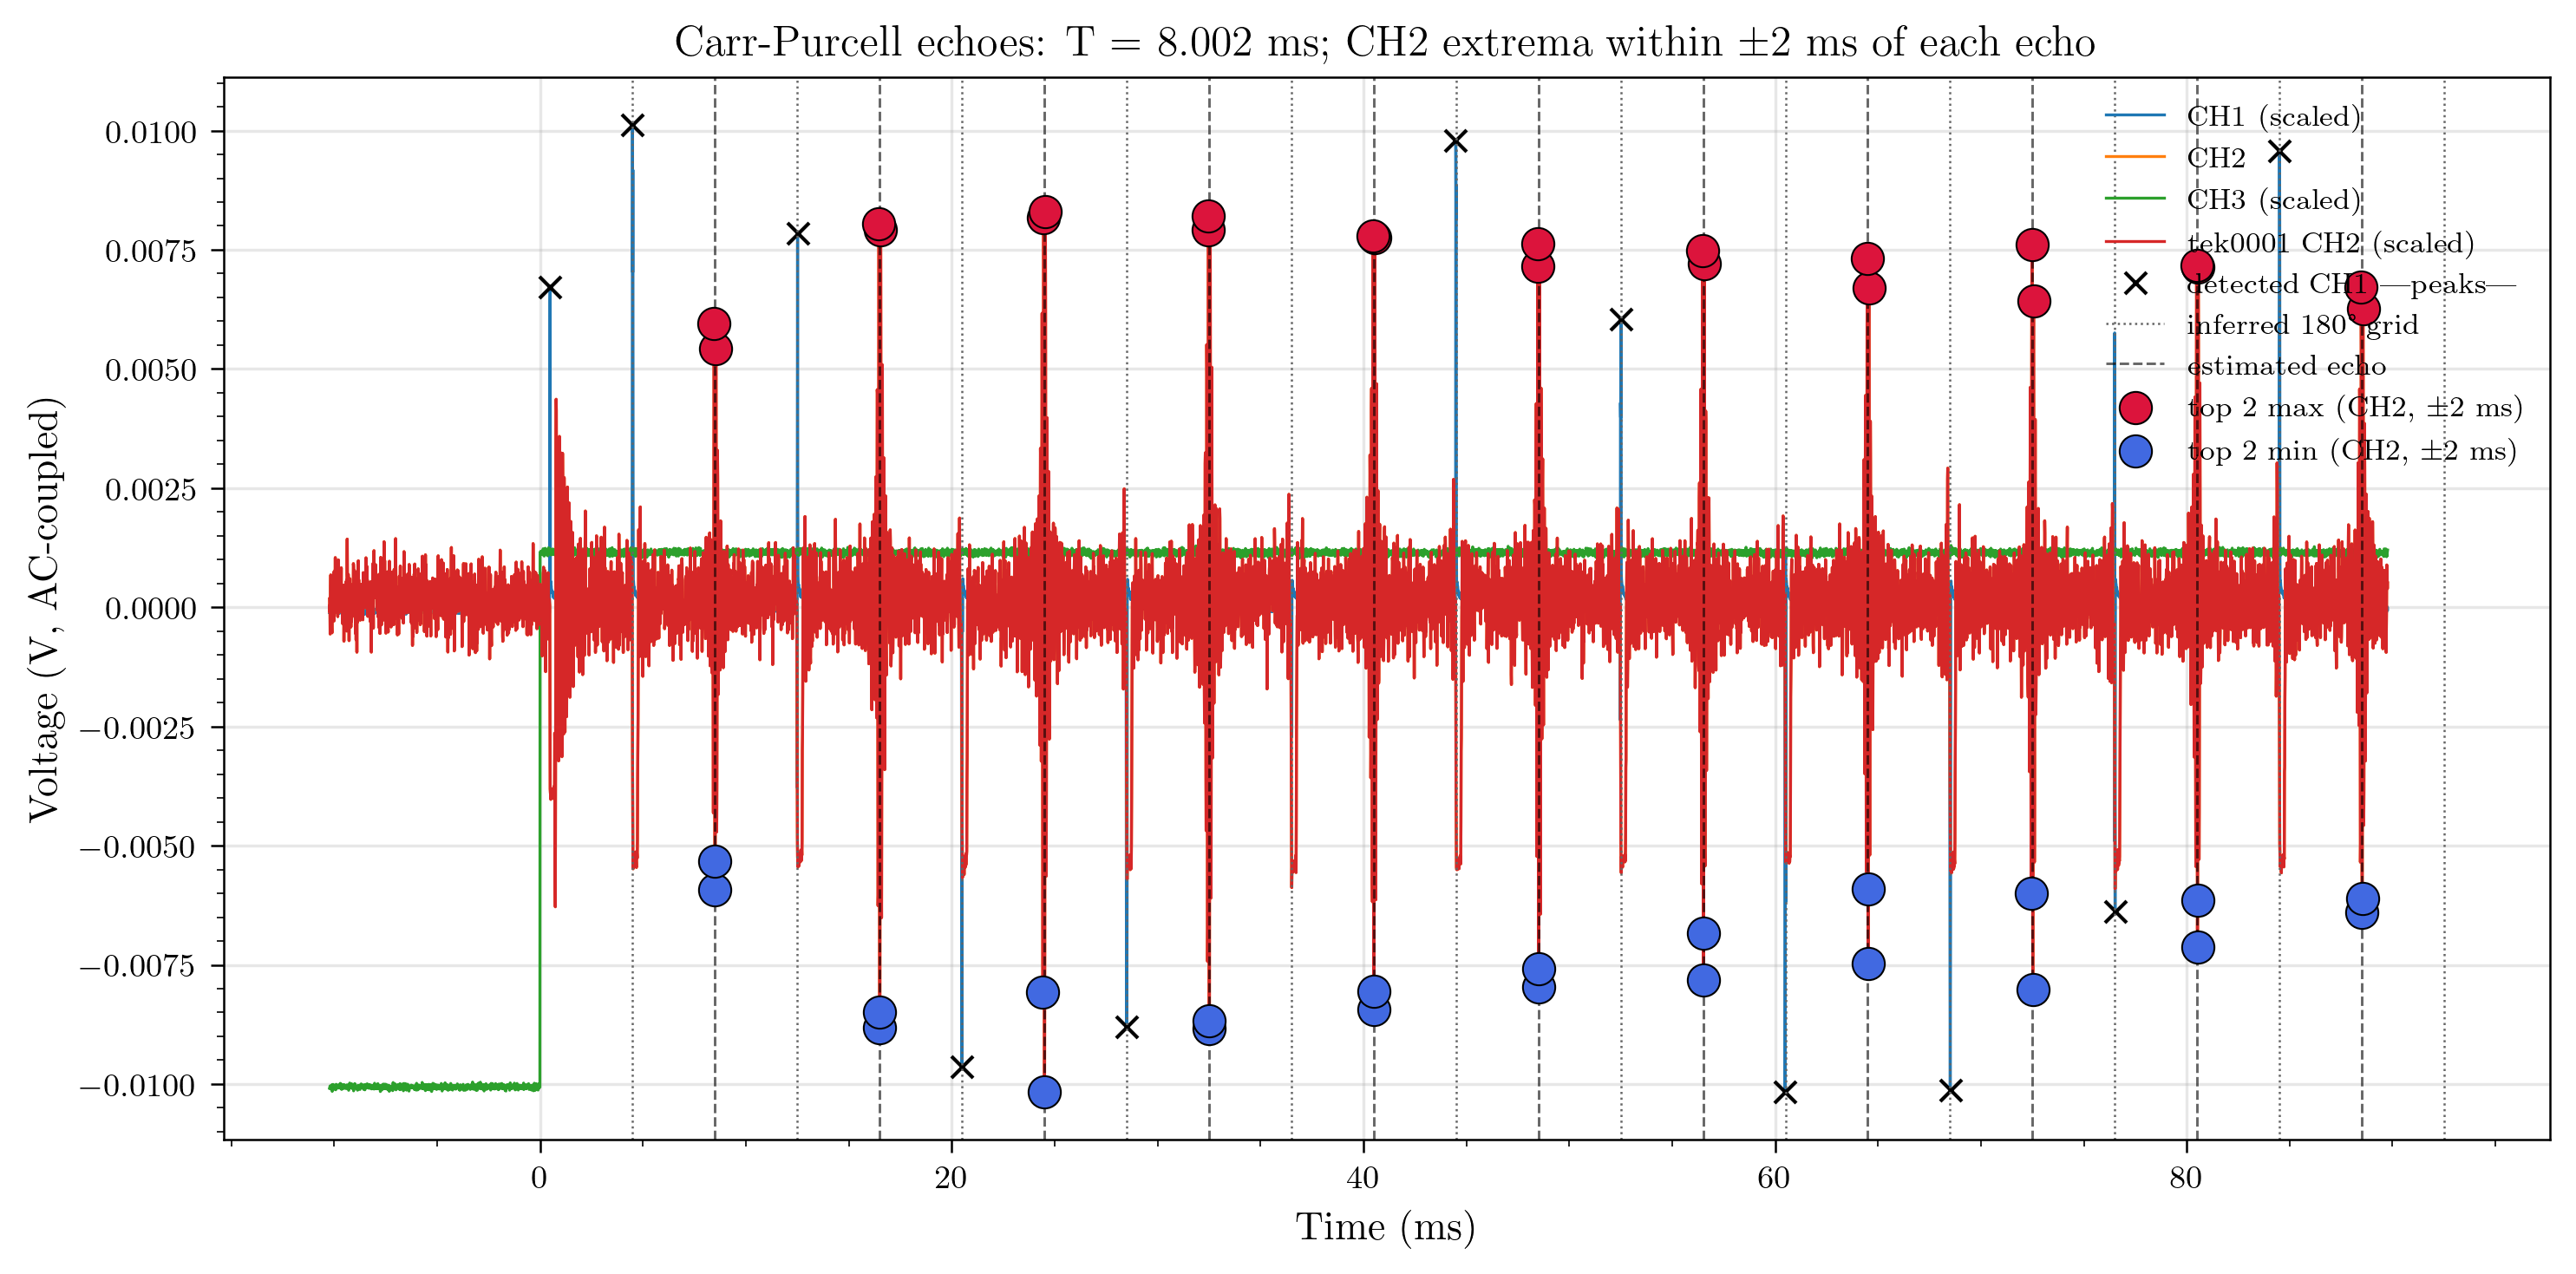

Detected 11 CH1 peaks; T = 8002.00 µs; 11 echo estimates


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

plt.style.use('./jlab.mplstyle')

# Per-echo amplitude sample size: pick the N most positive AND the N most
# negative CH2 values within ±window_s of each echo. Total points used per
# echo = 2 * N_EXTREMA. Increasing N averages over a wider window and
# reduces SEM but mixes more off-peak signal into the amplitude estimate.
# Used by cell 1 (single-file analysis) and the cell-2 sweep.
N_EXTREMA = 8

df = pd.read_csv('data/tek0000.csv', skiprows=20)
df = df[['TIME', 'CH1', 'CH2', 'CH3']].apply(pd.to_numeric, errors='coerce').dropna()

df1 = pd.read_csv('data/tek0001.csv', skiprows=20)
df1 = df1[['TIME', 'CH2']].apply(pd.to_numeric, errors='coerce').dropna()

t = df['TIME'].to_numpy()
# AC-couple: subtract the mean from every channel
ch1 = df['CH1'].to_numpy(copy=True); ch1 -= ch1.mean()
ch2 = df['CH2'].to_numpy(copy=True); ch2 -= ch2.mean()
ch3 = df['CH3'].to_numpy(copy=True); ch3 -= ch3.mean()

t1 = df1['TIME'].to_numpy()
ch2_1 = df1['CH2'].to_numpy(copy=True); ch2_1 -= ch2_1.mean()

ch2_max = np.max(np.abs(ch2))
ch1_scaled   = ch1   * (ch2_max / np.max(np.abs(ch1)))
ch3_scaled   = ch3   * (ch2_max / np.max(np.abs(ch3)))
ch2_1_scaled = ch2_1 * (ch2_max / np.max(np.abs(ch2_1)))

# --- Detect CH1 ± peaks
ch1_abs = np.abs(ch1)
peaks, _ = find_peaks(ch1_abs, height=0.5 * np.max(ch1_abs), distance=50)
peak_times = t[peaks]

# --- Uniform 180° spacing, drop the 90° (peak 0); fit T over the full span
later = peak_times[1:]
diffs = np.diff(later)
T_unit = np.min(diffs)
span = later[-1] - later[0]
n_int = int(round(span / T_unit))
T = span / n_int

# Inferred 180° grid + one extrapolated step
n_in_data = int(np.floor((t[-1] - later[0]) / T)) + 1
n_total = n_in_data + 1
t_180_grid = later[0] + np.arange(n_total) * T
echo_times = t_180_grid[:-1] + T / 2

# --- For each echo, find 2 most positive + 2 most negative CH2 points
# in a ±2 ms window
window_s = 2e-3
pos_t, pos_y, neg_t, neg_y = [], [], [], []
for te in echo_times:
    mask = (t >= te - window_s) & (t <= te + window_s)
    yi = ch2[mask]; ti = t[mask]
    if len(yi) < 4:
        continue
    order = np.argsort(yi)
    pos_t.extend(ti[order[-2:]]); pos_y.extend(yi[order[-2:]])
    neg_t.extend(ti[order[:2]]);  neg_y.extend(yi[order[:2]])

pos_t, pos_y = np.array(pos_t), np.array(pos_y)
neg_t, neg_y = np.array(neg_t), np.array(neg_y)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t  * 1e3, ch1_scaled,   label='CH1 (scaled)',         color='tab:blue',   lw=0.8)
ax.plot(t  * 1e3, ch2,          label='CH2',                  color='tab:orange', lw=0.8)
ax.plot(t  * 1e3, ch3_scaled,   label='CH3 (scaled)',         color='tab:green',  lw=0.8)
ax.plot(t1 * 1e3, ch2_1_scaled, label='tek0001 CH2 (scaled)', color='tab:red',    lw=0.8)

ax.plot(peak_times * 1e3, ch1_scaled[peaks], 'kx', ms=6, label='detected CH1 |peaks|')
for i, t180 in enumerate(t_180_grid):
    ax.axvline(t180 * 1e3, color='0.4', ls=':', lw=0.6,
               label='inferred 180° grid' if i == 0 else None)
for i, te in enumerate(echo_times):
    ax.axvline(te * 1e3, color='k', ls='--', lw=0.7, alpha=0.6,
               label='estimated echo' if i == 0 else None)

ax.scatter(pos_t * 1e3, pos_y, s=80, c='crimson',   zorder=5,
           edgecolor='black', lw=0.5, label='top 2 max (CH2, ±2 ms)')
ax.scatter(neg_t * 1e3, neg_y, s=80, c='royalblue', zorder=5,
           edgecolor='black', lw=0.5, label='top 2 min (CH2, ±2 ms)')

ax.set_xlabel('Time (ms)')
ax.set_ylabel('Voltage (V, AC-coupled)')
ax.set_title(f'Carr-Purcell echoes: T = {T*1e3:.3f} ms; CH2 extrema within ±2 ms of each echo')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Detected {len(peaks)} CH1 peaks; T = {T*1e6:.2f} µs; {len(echo_times)} echo estimates")

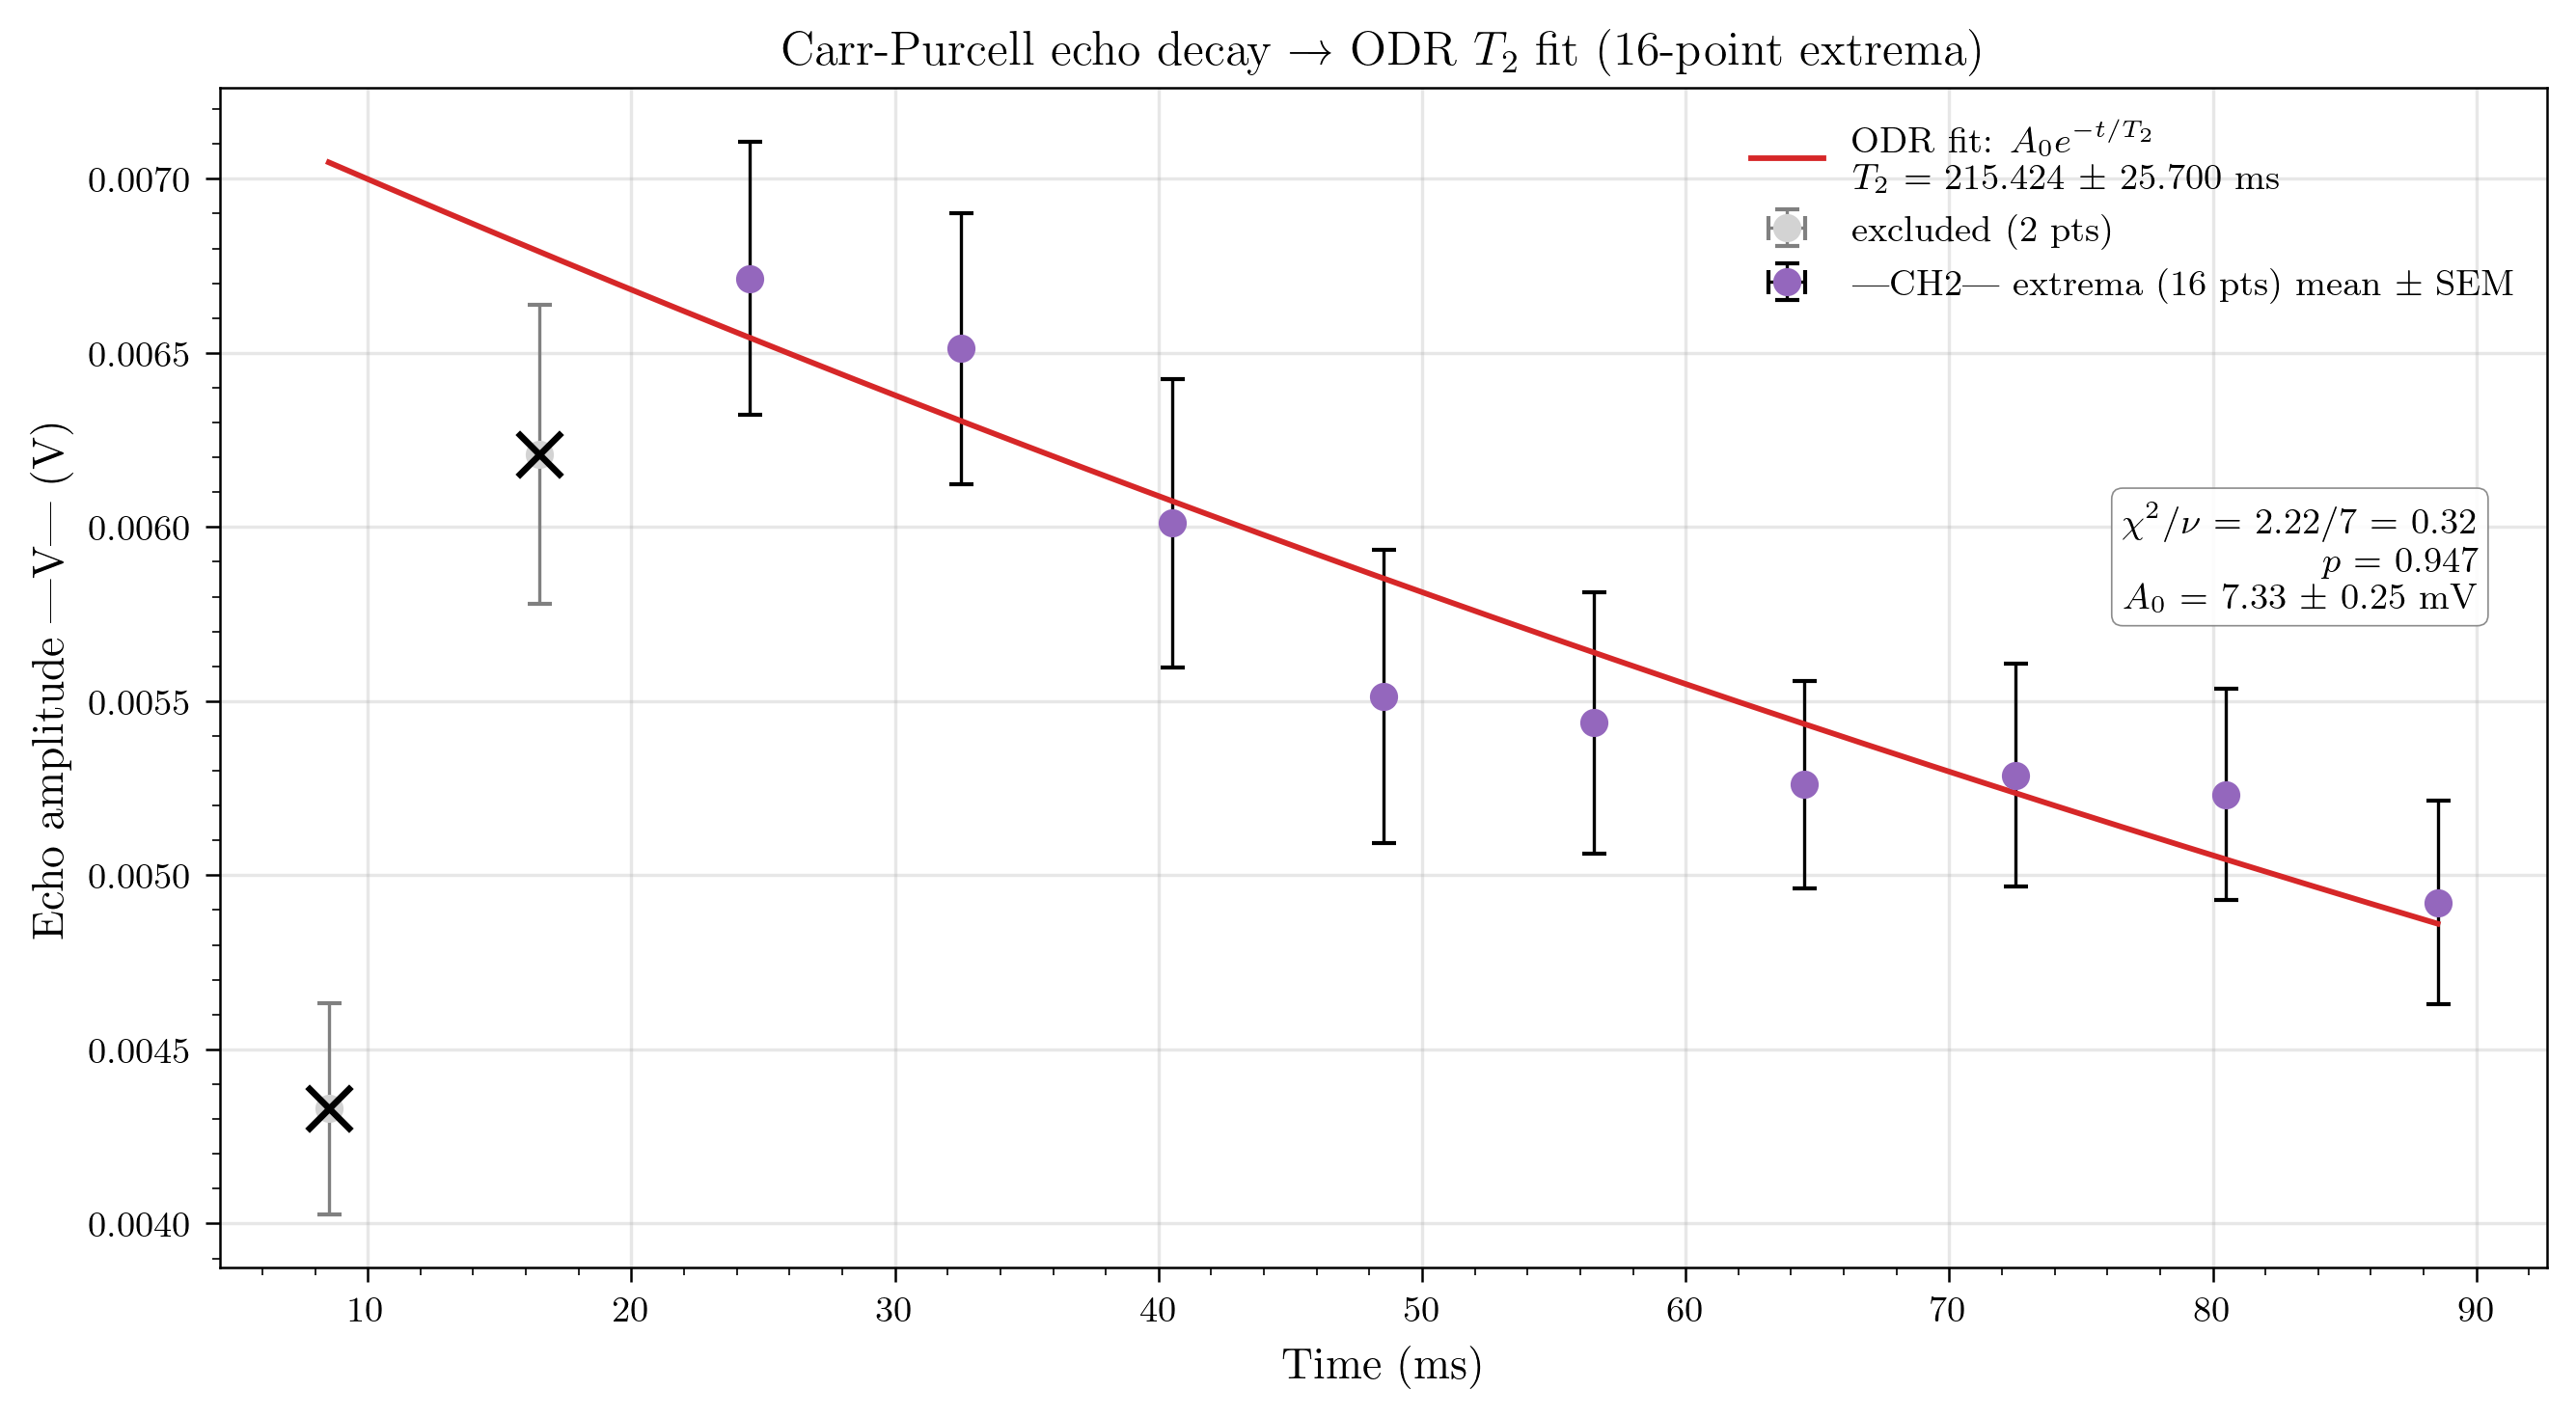

Fit on 9 points (skipped first 2; 8+/8- = 16 extrema/echo)
  A0 = 7.3315 ± 0.2486 mV
  T2 = 215.4243 ± 25.7004 ms
  χ²/ν = 2.221/7 = 0.317,  p = 0.9466


In [39]:
from scipy import odr
from scipy.stats import chi2 as chi2_dist

# N_EXTREMA is set at the top of cell 0.

# --- For each echo: pick |N_EXTREMA most positive| and |N_EXTREMA most
# negative| values. Compute mean amplitude, SEM, and the time spread
# (half-range) of those points to use as the horizontal uncertainty.
echo_t_kept, amp_mean, amp_sem, t_err = [], [], [], []
for te in echo_times:
    mask = (t >= te - window_s) & (t <= te + window_s)
    yi = ch2[mask]; ti = t[mask]
    if len(yi) < 2 * N_EXTREMA:
        continue
    order = np.argsort(yi)
    sel = np.concatenate([order[-N_EXTREMA:], order[:N_EXTREMA]])
    extrema_y = yi[sel]
    extrema_t = ti[sel]
    abs_vals = np.abs(extrema_y)
    echo_t_kept.append(np.mean(extrema_t))
    amp_mean.append(np.mean(abs_vals))
    amp_sem.append(np.std(abs_vals, ddof=1) / np.sqrt(len(abs_vals)))
    t_err.append((extrema_t.max() - extrema_t.min()) / 2)

echo_t_kept = np.array(echo_t_kept)
amp_mean    = np.array(amp_mean)
amp_sem     = np.array(amp_sem)
t_err       = np.array(t_err)

# --- Drop the first few points before fitting; still plot them with X overlay
n_skip = 2
fit_t      = echo_t_kept[n_skip:]
fit_amp    = amp_mean[n_skip:]
fit_sem    = amp_sem[n_skip:]
fit_t_err  = t_err[n_skip:]

# ODR fit to A0 * exp(-t / T2)
def exp_decay_model(beta, t):
    return beta[0] * np.exp(-t / beta[1])

model = odr.Model(exp_decay_model)
sx = np.where(fit_t_err > 0, fit_t_err, np.min(np.diff(t)))
data = odr.RealData(fit_t, fit_amp, sx=sx, sy=fit_sem)
beta0 = [fit_amp[0], (fit_t[-1] - fit_t[0]) / 2]
out = odr.ODR(data, model, beta0=beta0).run()

A0_fit, T2_fit = out.beta
A0_err, T2_err = out.sd_beta
chi2_val   = out.sum_square
dof        = len(fit_t) - 2
chi2_red   = chi2_val / dof
p_value    = chi2_dist.sf(chi2_val, df=dof)

t_fine = np.linspace(echo_t_kept[0], echo_t_kept[-1], 400)

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(echo_t_kept[:n_skip] * 1e3, amp_mean[:n_skip],
            xerr=t_err[:n_skip] * 1e3, yerr=amp_sem[:n_skip],
            fmt='o', ms=6, color='lightgray', ecolor='gray',
            elinewidth=0.8, capsize=3, label=f'excluded ({n_skip} pts)')
ax.scatter(echo_t_kept[:n_skip] * 1e3, amp_mean[:n_skip],
           marker='x', s=120, c='black', lw=1.6, zorder=6)
ax.errorbar(fit_t * 1e3, fit_amp, xerr=fit_t_err * 1e3, yerr=fit_sem,
            fmt='o', ms=6, color='tab:purple', ecolor='black',
            elinewidth=0.8, capsize=3,
            label=f'|CH2| extrema ({2 * N_EXTREMA} pts) mean ± SEM')
ax.plot(t_fine * 1e3, exp_decay_model(out.beta, t_fine),
        '-', color='tab:red', lw=1.4,
        label=f'ODR fit: $A_0 e^{{-t/T_2}}$\n$T_2$ = {T2_fit*1e3:.3f} ± {T2_err*1e3:.3f} ms')

stats_txt = (f'$\\chi^2/\\nu$ = {chi2_val:.2f}/{dof} = {chi2_red:.2f}\n'
             f'$p$ = {p_value:.3f}\n'
             f'$A_0$ = {A0_fit*1e3:.2f} ± {A0_err*1e3:.2f} mV')
ax.text(0.97, 0.65, stats_txt, transform=ax.transAxes, ha='right', va='top',
        fontsize=9, bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.9))

ax.set_xlabel('Time (ms)')
ax.set_ylabel('Echo amplitude |V| (V)')
ax.set_title(f'Carr-Purcell echo decay → ODR $T_2$ fit ({2 * N_EXTREMA}-point extrema)')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f"Fit on {len(fit_t)} points (skipped first {n_skip}; "
      f"{N_EXTREMA}+/{N_EXTREMA}- = {2 * N_EXTREMA} extrema/echo)")
print(f"  A0 = {A0_fit*1e3:.4f} ± {A0_err*1e3:.4f} mV")
print(f"  T2 = {T2_fit*1e3:.4f} ± {T2_err*1e3:.4f} ms")
print(f"  χ²/ν = {chi2_val:.3f}/{dof} = {chi2_red:.3f},  p = {p_value:.4f}")

T_rec  T_corr   sigT   file  res  n_skip     T2 (ms)    sig_T2   chi2/nu        p
-------------------------------------------------------------------------------------
 54.0   53.19   0.81  0035   hi       3       88.28      2.18     0.811   0.5778
 55.0   53.93   1.07  0017   lo       0       96.83     12.19     1.783   0.0751
 55.0   54.35   0.65  0019   lo       2       99.55     11.29     0.858   0.5387
 57.5   56.14   1.36  0036   hi       3       94.11      4.84     3.593   0.0007
 60.0   58.84   1.16  0020   lo       1      105.50      6.90     0.376   0.8949
 62.5   60.53   1.97  0038   hi       3      104.24      5.27     3.451   0.0011
 65.0   63.66   1.34  0021   lo       4      125.88     10.74     0.503   0.7739
 65.0   63.74   1.26  0022   lo       3      124.04     14.91     1.859   0.0836
 66.0   63.45   2.55  0039   hi       4      150.07      5.93     0.393   0.8839
 67.5   66.34   1.16  0027   lo       2      152.58     13.86     0.776   0.5886
 68.5   66.42   2.08  

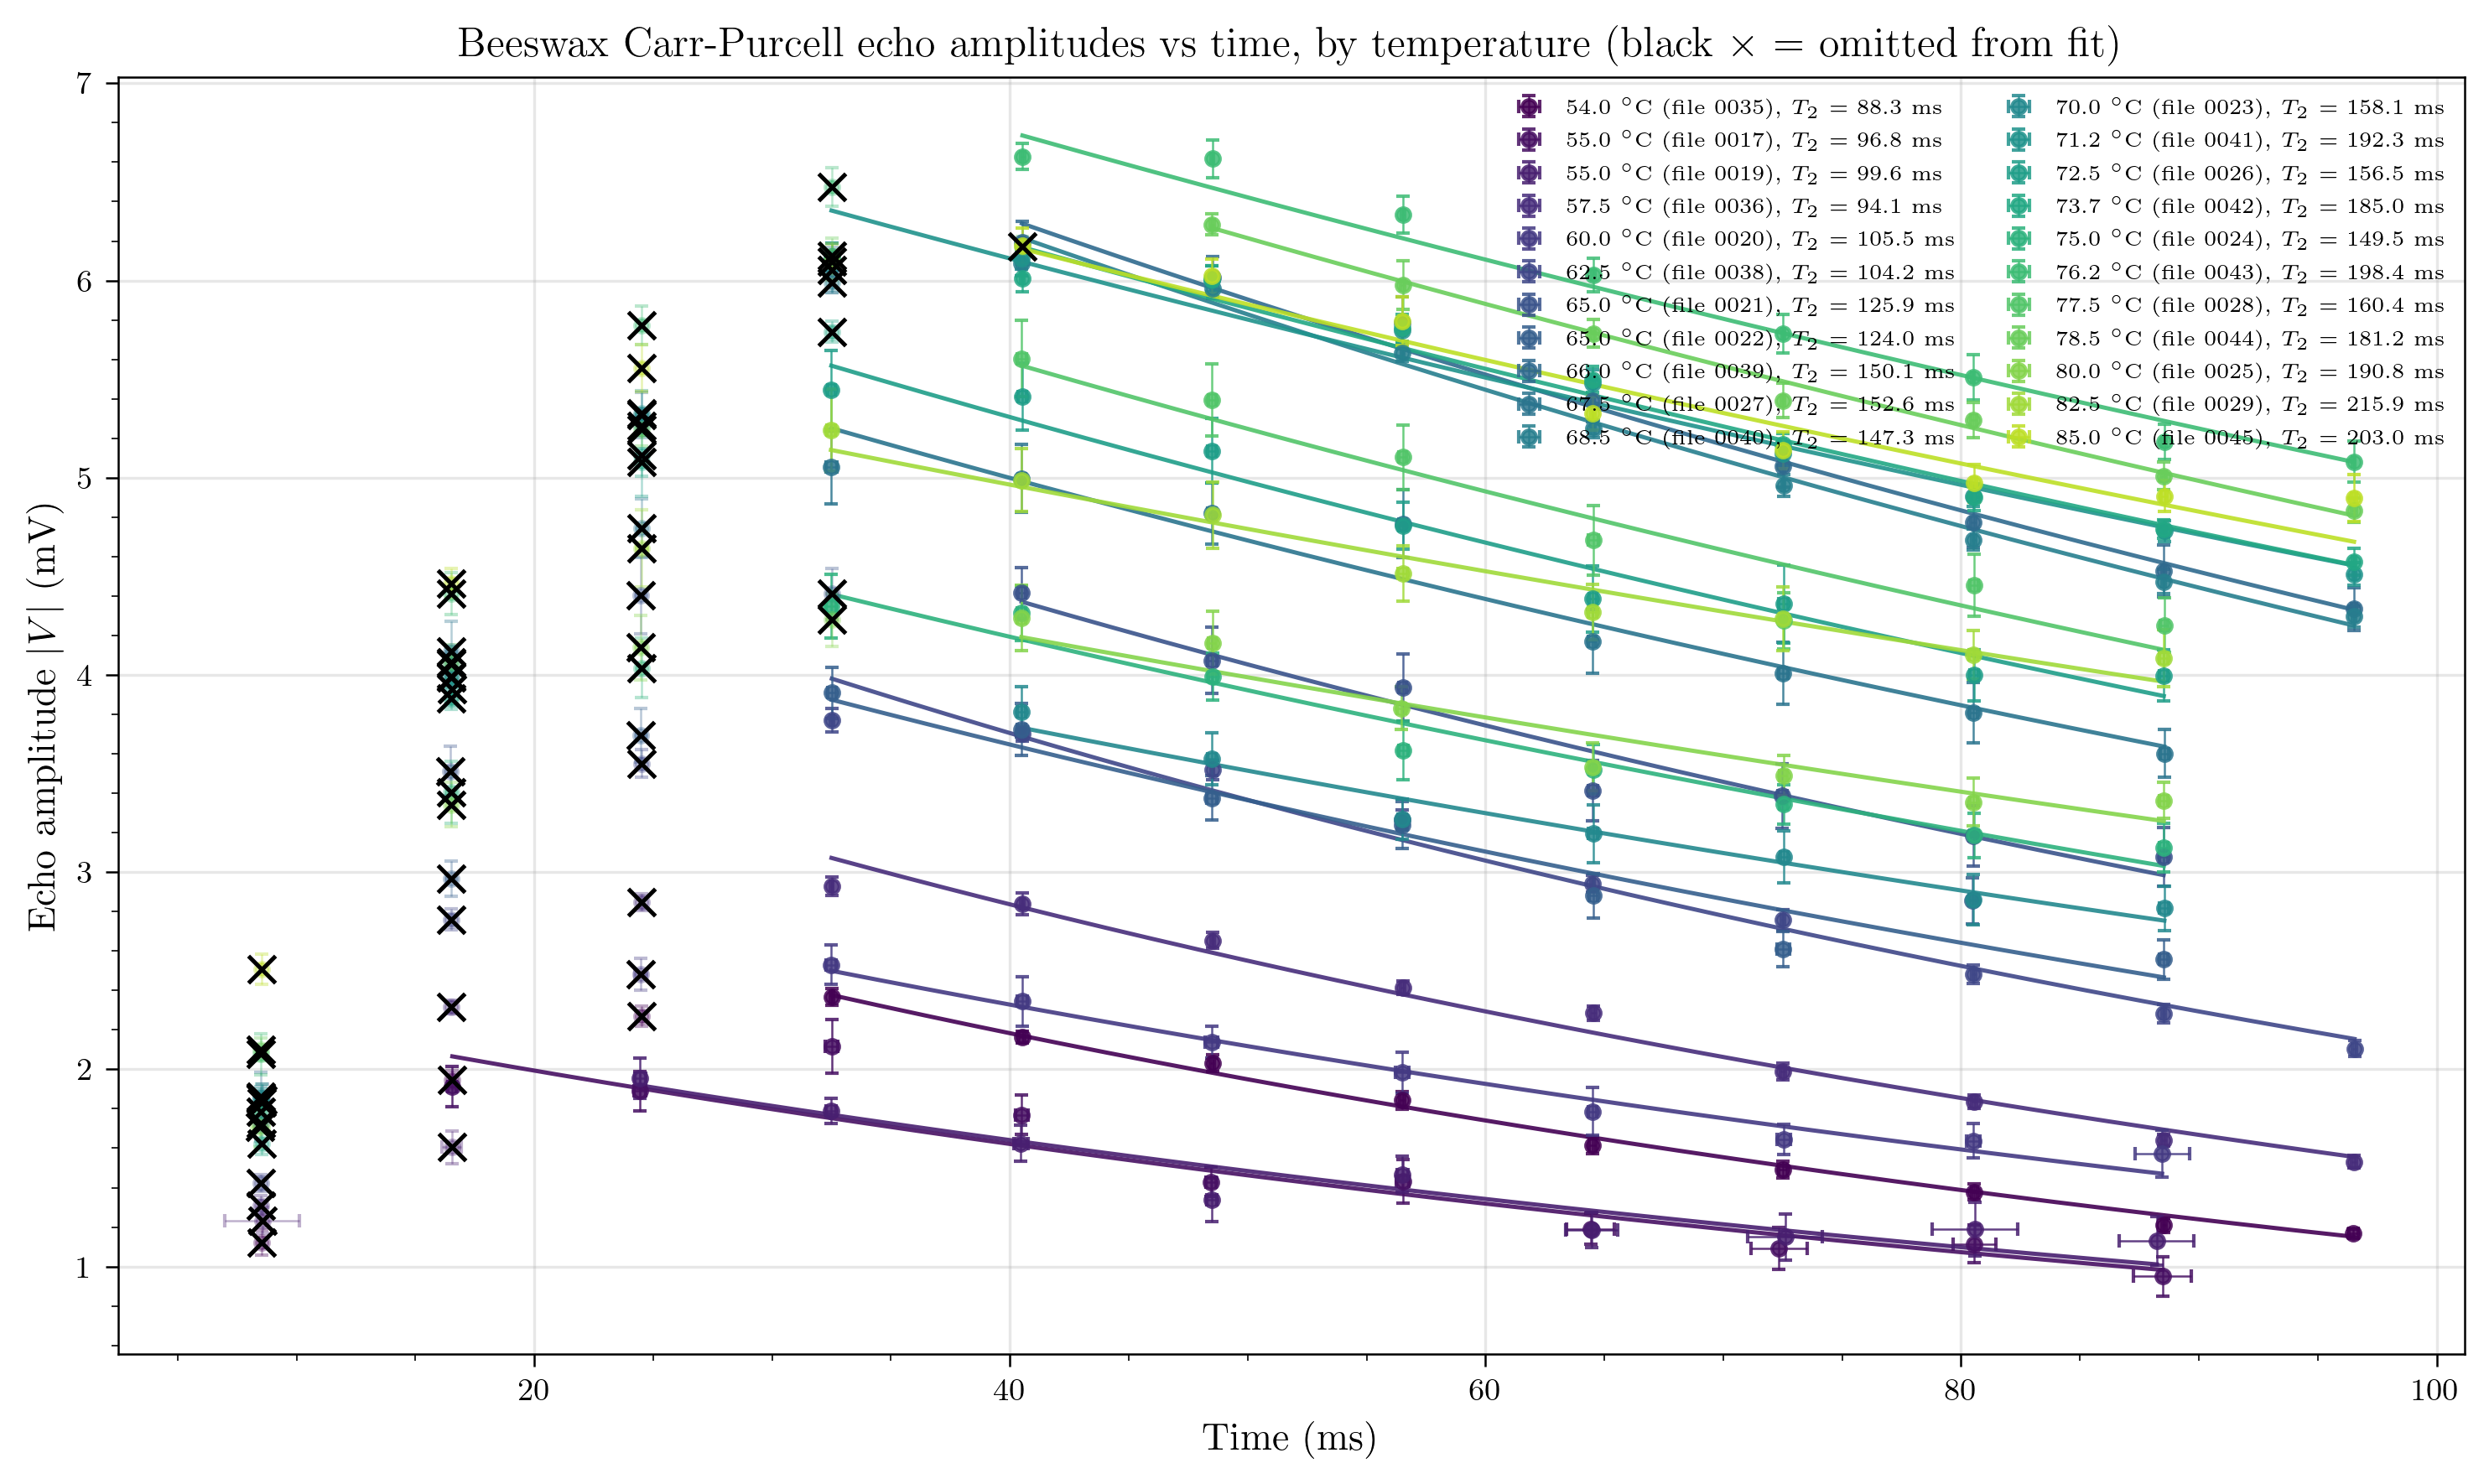

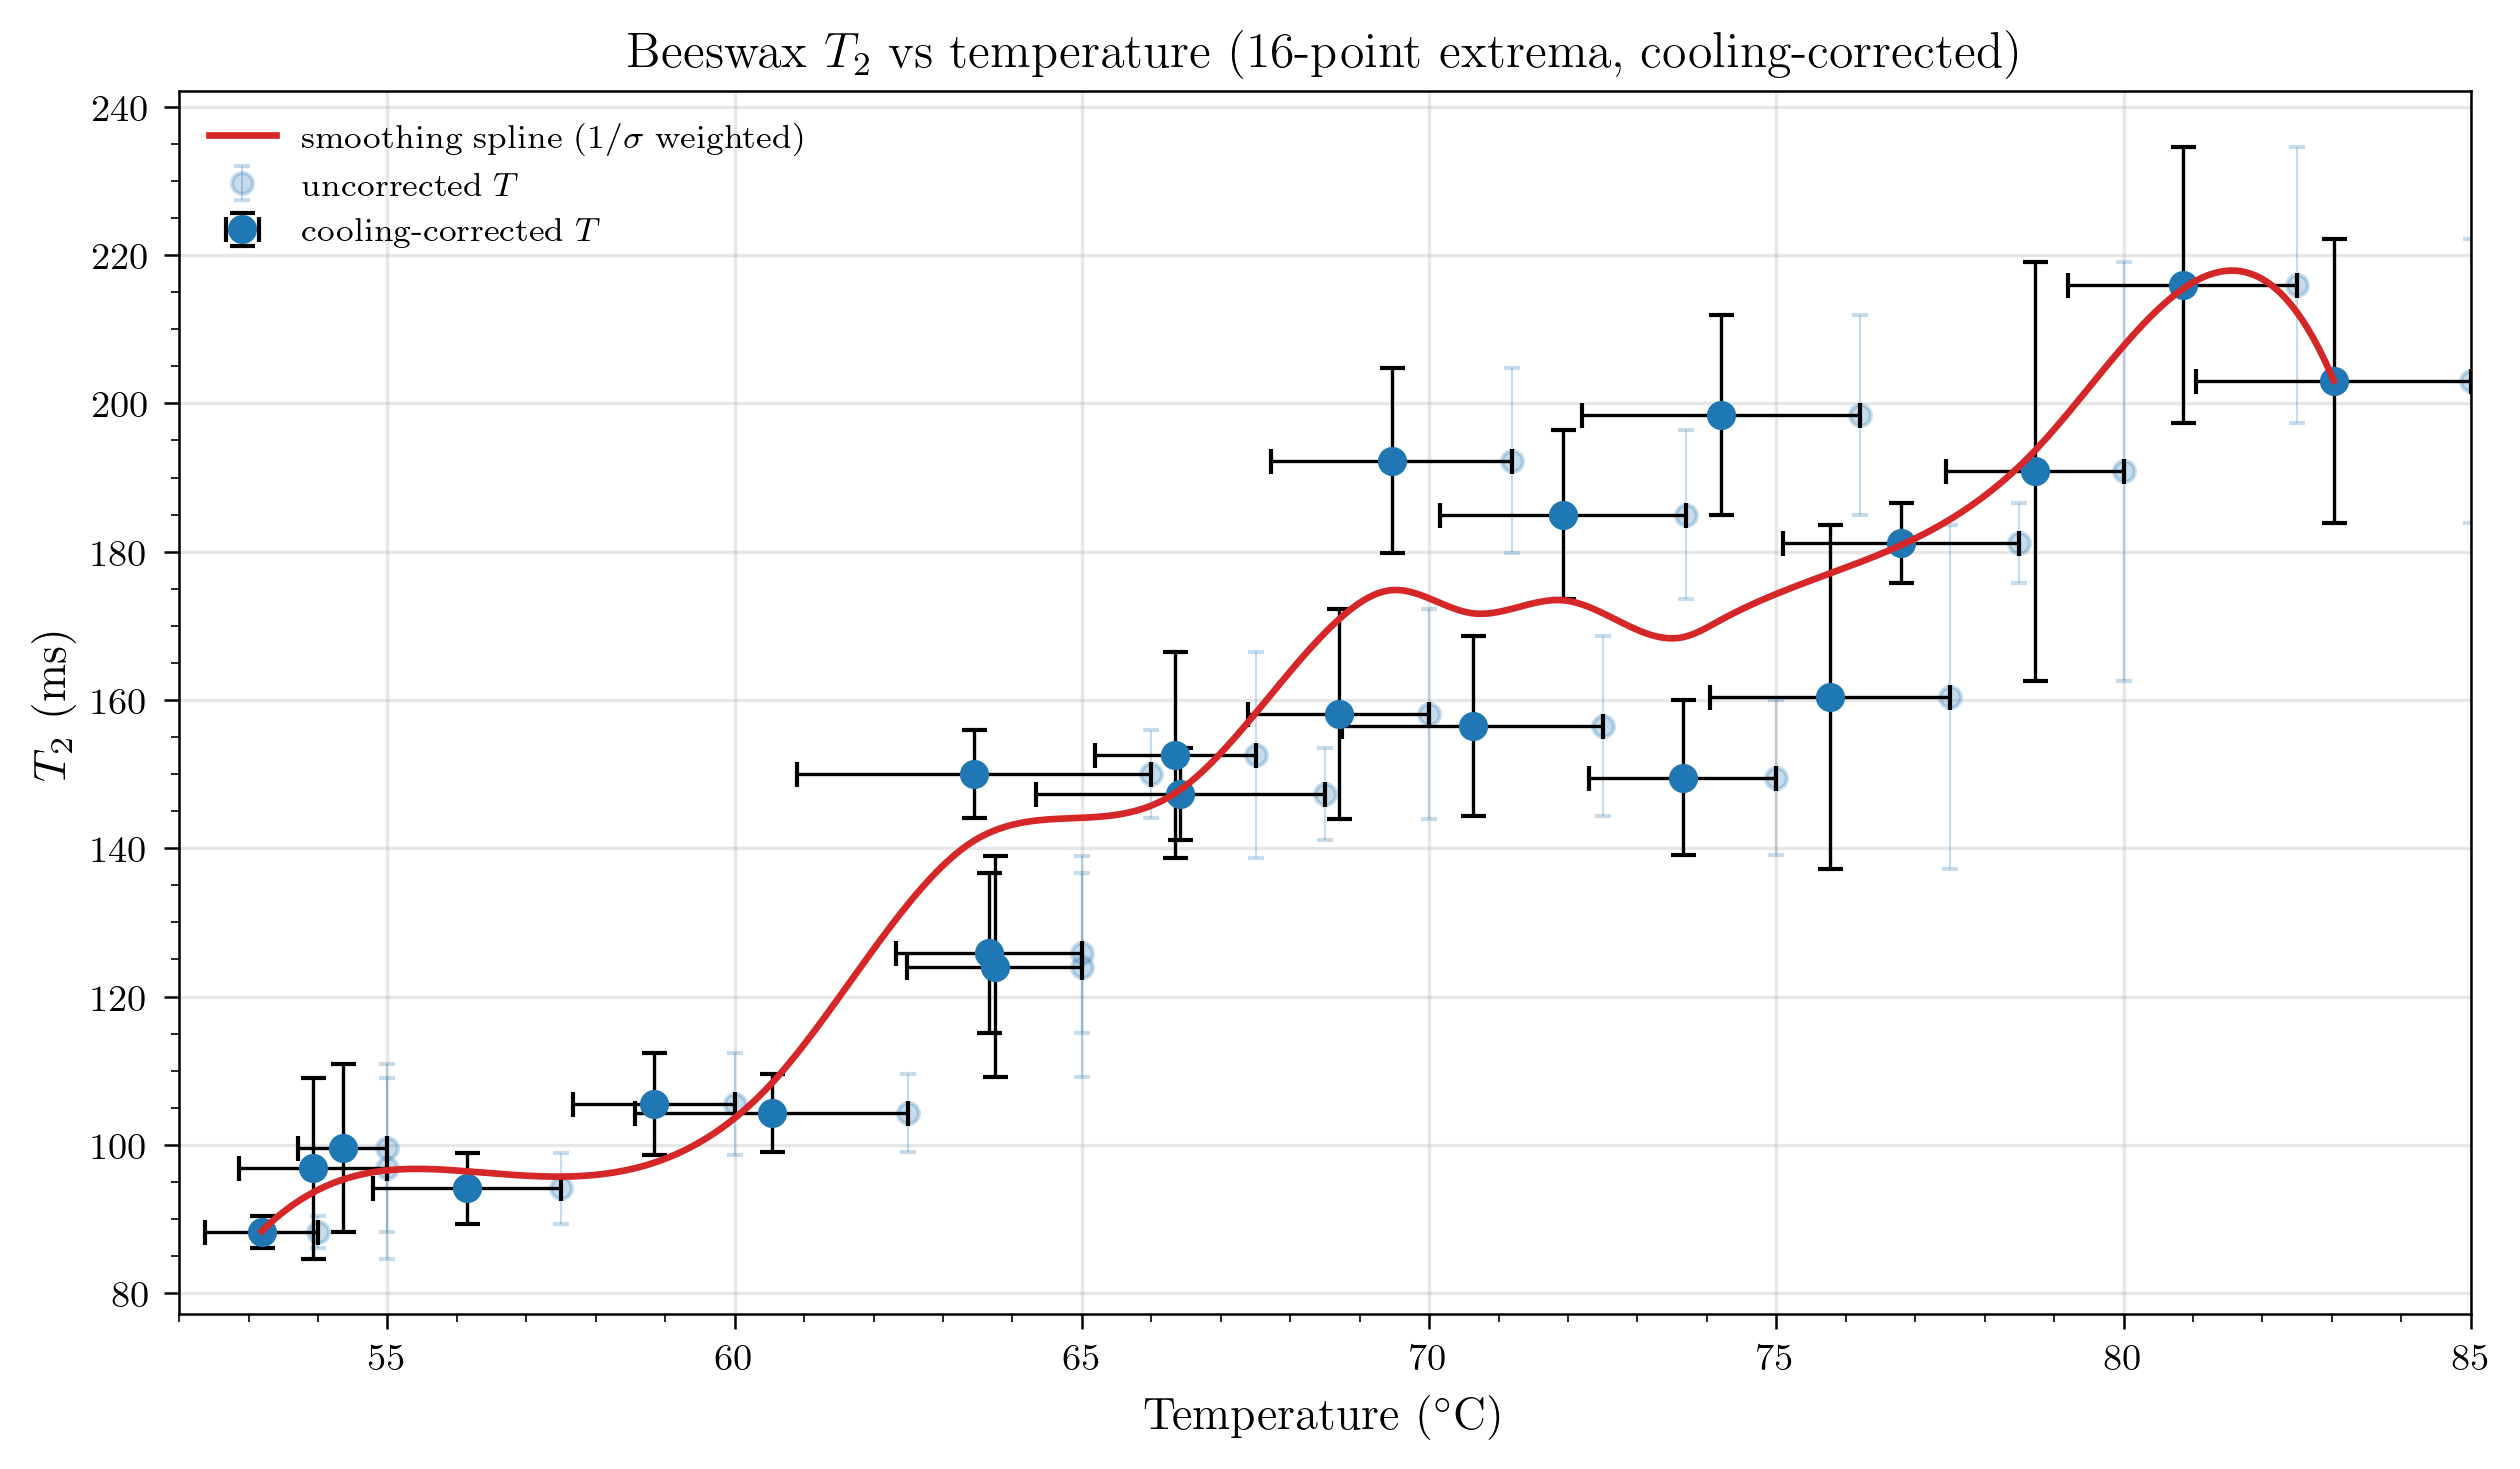


12 10k-sample + 10 100k-sample T2 points (16 extrema/echo)


In [40]:
import matplotlib.cm as cm
from scipy.interpolate import UnivariateSpline

# --- Parse NMR_samples.csv: every "big" beeswax row at T >= T_MIN. Don't
# drop duplicate temperatures — each file becomes its own point.
T_MIN         = 54.0
HIRES_MIN     = 31      # files >= 31 are 100k-sample / 1 us recordings
SHOW_OLD_DATA = False   # toggle archival nmr_old/bwax T2 points on Plot 2
UNIFY_RES     = True    # plot hi-res and lo-res with the same color/marker
# N_EXTREMA inherited from cell 1 (USE_TWO_POINTS toggle: 1 → 2 points/echo,
# 2 → 4 points/echo). Default to 1 if cell 1 hasn't been run.
N_EXTREMA     = globals().get('N_EXTREMA', 1)

samples = pd.read_csv('data/NMR_samples.csv', skiprows=2, header=None,
                     names=['temp_C', 'file_num', 'time_diff_s', 'col1',
                            'sample_size', 'extra'])
samples['sample_size'] = samples['sample_size'].astype(str).str.strip()
samples = samples[samples['sample_size'] == 'big'].copy()
samples['temp_C']      = pd.to_numeric(samples['temp_C'],      errors='coerce')
samples['file_num']    = pd.to_numeric(samples['file_num'],    errors='coerce')
samples['time_diff_s'] = pd.to_numeric(samples['time_diff_s'], errors='coerce')
samples = samples.dropna(subset=['temp_C', 'file_num', 'time_diff_s'])
samples = samples[samples['temp_C'] >= T_MIN]
samples['file_num'] = samples['file_num'].astype(int)
chosen = samples.sort_values(['temp_C', 'file_num'])


# --- Cooling-rate model: averaged |dT/dt|(T) from the 5 calibration curves.
def build_dTdt():
    cal = pd.read_csv('../nmr_old/beeswax_temp_calibration.csv', header=None,
                      skiprows=2,
                      names=['T', 't2', 'u2', 't6', 'u6', 't10', 'u10',
                             't16', 'u16', 't18', 'u18'])
    cal['T'] = pd.to_numeric(cal['T'], errors='coerce')
    cal = cal.dropna(subset=['T']).reset_index(drop=True)
    T_cal = cal['T'].to_numpy(float)

    samples_T, samples_dTdt = [], []
    for col in ['t2', 't6', 't10', 't16', 't18']:
        t_col = pd.to_numeric(cal[col], errors='coerce').to_numpy(float)
        valid = ~np.isnan(t_col)
        if valid.sum() < 3:
            continue
        Tv, tv = T_cal[valid], t_col[valid]
        dTdt = np.gradient(Tv, tv)
        samples_T.append(Tv); samples_dTdt.append(np.abs(dTdt))

    T_all   = np.concatenate(samples_T)
    dTdt_all = np.concatenate(samples_dTdt)
    order   = np.argsort(T_all)
    return T_all[order], dTdt_all[order]


T_grid, dTdt_grid = build_dTdt()


def cooling_rate(T_C):
    return np.interp(T_C, T_grid, dTdt_grid)


def extract_echoes(file_num, window_s=2e-3, n_extrema=N_EXTREMA):
    """Return (echo_t, amp_mean, amp_sem, t_err) for one tek file, or None.
    Picks `n_extrema` most positive + most negative CH2 values per echo.
    Auto-scales the peak-distance to ~500 us so it works for both the
    10k-sample (10 us spacing) and 100k-sample (1 us spacing) recordings."""
    fname = f'data/tek{file_num:04d}.csv'
    d = pd.read_csv(fname, skiprows=20)
    cols = ['TIME', 'CH1', 'CH2']
    d = d[cols].apply(pd.to_numeric, errors='coerce').dropna()
    tt = d['TIME'].to_numpy()
    c1 = d['CH1'].to_numpy(copy=True); c1 -= c1.mean()
    c2 = d['CH2'].to_numpy(copy=True); c2 -= c2.mean()

    sample_dt = float(np.median(np.diff(tt)))
    peak_dist = max(10, int(round(500e-6 / sample_dt)))

    pks, _ = find_peaks(np.abs(c1), height=0.5 * np.max(np.abs(c1)),
                        distance=peak_dist)
    if len(pks) < 3:
        return None
    pt = tt[pks]
    later = pt[1:]
    if len(later) < 2:
        return None
    Tunit = np.min(np.diff(later))
    span = later[-1] - later[0]
    nint = max(1, int(round(span / Tunit)))
    Tp = span / nint
    n_in = int(np.floor((tt[-1] - later[0]) / Tp)) + 1
    grid = later[0] + np.arange(n_in + 1) * Tp
    echoes = grid[:-1] + Tp / 2

    et, am, ase, te = [], [], [], []
    for x in echoes:
        m = (tt >= x - window_s) & (tt <= x + window_s)
        yi = c2[m]; ti = tt[m]
        if len(yi) < 2 * n_extrema:
            continue
        order = np.argsort(yi)
        sel = np.concatenate([order[-n_extrema:], order[:n_extrema]])
        ey = yi[sel]; tx = ti[sel]
        absv = np.abs(ey)
        et.append(np.mean(tx))
        am.append(np.mean(absv))
        ase.append(np.std(absv, ddof=1) / np.sqrt(len(absv)))
        te.append((tx.max() - tx.min()) / 2)
    return np.array(et), np.array(am), np.array(ase), np.array(te)


def find_n_skip(am):
    for i in range(len(am) - 1):
        if am[i + 1] < am[i]:
            return i
    return None


def fit_T2(et, am, ase, te, n_skip):
    if len(et) - n_skip < 3:
        return None
    fit_t = et[n_skip:]; fit_a = am[n_skip:]
    fit_s = ase[n_skip:]; fit_e = te[n_skip:]
    sx = np.where(fit_e > 0, fit_e, 1e-6)

    def model(beta, t):
        return beta[0] * np.exp(-t / beta[1])

    out = odr.ODR(odr.RealData(fit_t, fit_a, sx=sx, sy=fit_s),
                  odr.Model(model),
                  beta0=[fit_a[0], (fit_t[-1] - fit_t[0]) / 2]).run()
    A0, T2v   = out.beta
    A0e, T2e  = out.sd_beta
    chi2v     = out.sum_square
    dofv      = len(fit_t) - 2
    pv        = chi2_dist.sf(chi2v, df=dofv)
    return dict(A0=A0, A0_err=A0e, T2=T2v, T2_err=T2e,
                chi2=chi2v, dof=dofv, p=pv,
                fit_t=fit_t, fit_a=fit_a, fit_s=fit_s, fit_e=fit_e)


# --- Run extraction + fit for each row
results = []
cmap = cm.viridis(np.linspace(0, 0.9, len(chosen)))

print(f"{'T_rec':>5}  {'T_corr':>6}  {'sigT':>5}  {'file':>5}  {'res':>3}  "
      f"{'n_skip':>6}  {'T2 (ms)':>10}  {'sig_T2':>8}  "
      f"{'chi2/nu':>8}  {'p':>7}")
print("-" * 85)

for color, (_, row) in zip(cmap, chosen.iterrows()):
    fnum    = int(row['file_num'])
    T_rec   = float(row['temp_C'])
    dt_wait = float(row['time_diff_s'])
    hires   = fnum >= HIRES_MIN

    delta    = dt_wait * float(cooling_rate(T_rec))
    T_corr   = T_rec - 0.5 * delta
    T_corr_u = 0.5 * delta

    ext = extract_echoes(fnum)
    if ext is None:
        print(f"{T_rec:>5.1f}  {T_corr:>6.2f}  {T_corr_u:>5.2f}  "
              f"{fnum:04d}  {'hi' if hires else 'lo':>3}   extraction failed")
        continue
    et, am, ase, te = ext
    n_skip = find_n_skip(am)
    if n_skip is None:
        print(f"{T_rec:>5.1f}  {T_corr:>6.2f}  {T_corr_u:>5.2f}  "
              f"{fnum:04d}  {'hi' if hires else 'lo':>3}   no decreasing trend")
        continue
    fit = fit_T2(et, am, ase, te, n_skip=n_skip)
    results.append(dict(T_rec=T_rec, T_corr=T_corr, T_corr_u=T_corr_u,
                        file=fnum, color=color, n_skip=n_skip, hires=hires,
                        et=et, am=am, ase=ase, te=te, fit=fit))
    if fit is None:
        print(f"{T_rec:>5.1f}  {T_corr:>6.2f}  {T_corr_u:>5.2f}  "
              f"{fnum:04d}  {'hi' if hires else 'lo':>3}  {n_skip:>6d}   "
              f"too few points after skip")
    else:
        print(f"{T_rec:>5.1f}  {T_corr:>6.2f}  {T_corr_u:>5.2f}  "
              f"{fnum:04d}  {'hi' if hires else 'lo':>3}  {n_skip:>6d}  "
              f"{fit['T2']*1e3:>10.2f}  {fit['T2_err']*1e3:>8.2f}  "
              f"{fit['chi2']/fit['dof']:>8.3f}  {fit['p']:>7.4f}")

# --- Plot 1: all echo amplitudes; omitted points are shown but marked with X
fig, ax = plt.subplots(figsize=(10, 6))
for r in results:
    n = r['n_skip']
    lbl = f"{r['T_rec']:.1f} $^\\circ$C (file {r['file']:04d})"
    if r['fit'] is not None:
        lbl += f", $T_2$ = {r['fit']['T2']*1e3:.1f} ms"
    ax.errorbar(r['et'][n:] * 1e3, r['am'][n:] * 1e3,
                xerr=r['te'][n:] * 1e3, yerr=r['ase'][n:] * 1e3,
                fmt='o', ms=4, color=r['color'], ecolor=r['color'],
                elinewidth=0.6, capsize=2, alpha=0.85, label=lbl)
    if n > 0:
        ax.errorbar(r['et'][:n] * 1e3, r['am'][:n] * 1e3,
                    xerr=r['te'][:n] * 1e3, yerr=r['ase'][:n] * 1e3,
                    fmt='o', ms=4, color=r['color'], ecolor=r['color'],
                    elinewidth=0.6, capsize=2, alpha=0.35)
        ax.scatter(r['et'][:n] * 1e3, r['am'][:n] * 1e3,
                   marker='x', s=60, c='black', lw=1.2, zorder=6)
    if r['fit'] is not None:
        f = r['fit']
        tf = np.linspace(f['fit_t'][0], f['fit_t'][-1], 200)
        ax.plot(tf * 1e3, f['A0'] * np.exp(-tf / f['T2']) * 1e3,
                '-', color=r['color'], lw=1.2, alpha=0.9)

ax.set_xlabel('Time (ms)')
ax.set_ylabel('Echo amplitude $|V|$ (mV)')
ax.set_title('Beeswax Carr-Purcell echo amplitudes vs time, by temperature '
             '(black $\\times$ = omitted from fit)')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=6, ncol=2)
plt.tight_layout()
plt.show()


# --- Old (nmr_old/bwax_data_new.csv) T2 values, replicated from bwax.ipynb.
def load_old_T2():
    df = pd.read_csv('../nmr_old/bwax_data_new.csv', header=0)
    tau_row = df.iloc[0]
    temp_df = df.iloc[2:14]
    calib_px_row = df.iloc[14]
    calib_mV_row = df.iloc[15]
    val_slice = slice(1, None, 2); unc_slice = slice(2, None, 2)

    temperatures = temp_df.iloc[:, 0].values.astype(float)
    raw_px  = temp_df.iloc[:, val_slice].values.astype(float)
    raw_unc = temp_df.iloc[:, unc_slice].values.astype(float)
    taus    = tau_row.iloc[val_slice].values.astype(float)
    calib_px = calib_px_row.iloc[val_slice].values.astype(float)
    calib_uc = calib_px_row.iloc[unc_slice].values.astype(float)
    calib_mV = calib_mV_row.iloc[val_slice].values.astype(float)

    slope = (80 - 23.8) / (70 - 23.8)
    T_act = slope * (temperatures - 23.8) + 23.8
    T_unc = (5 / (70 - 23.8)) * (temperatures - 23.8)

    scale = calib_mV / calib_px
    amp_mV = raw_px * scale[None, :]
    amp_unc_mV = amp_mV * np.sqrt((raw_unc / raw_px) ** 2 +
                                  (calib_uc / calib_px) ** 2)

    fit_mask = np.isin(taus, [10, 16, 18])
    taus_fit = taus[fit_mask]

    def exp_decay(tau, A0, T2):
        return A0 * np.exp(-2 * tau / T2)

    T2_arr = np.full(len(T_act), np.nan)
    T2_err = np.full(len(T_act), np.nan)
    for i in range(len(T_act)):
        y = amp_mV[i, fit_mask]; yerr = amp_unc_mV[i, fit_mask]
        try:
            from scipy.optimize import curve_fit
            popt, pcov = curve_fit(exp_decay, taus_fit, y,
                                   p0=[y[0] * np.exp(taus_fit[0] / 15), 15.0],
                                   sigma=yerr, absolute_sigma=True)
            T2_arr[i] = popt[1]; T2_err[i] = np.sqrt(pcov[1, 1])
        except Exception:
            pass
    return T_act, T_unc, T2_arr, T2_err


# --- Plot 2: T2 vs temperature; uncorrected (faded) + cooling-corrected
fitted = [r for r in results
          if r['fit'] is not None
          and np.isfinite(r['fit']['T2_err'])
          and r['fit']['T2_err'] < 5 * r['fit']['T2']]

lo = [r for r in fitted if not r['hires']]
hi = [r for r in fitted if     r['hires']]

def arrs(group):
    Tr  = np.array([r['T_rec']    for r in group])
    Tc  = np.array([r['T_corr']   for r in group])
    Tcu = np.array([r['T_corr_u'] for r in group])
    T2  = np.array([r['fit']['T2']     for r in group]) * 1e3
    T2e = np.array([r['fit']['T2_err'] for r in group]) * 1e3
    return Tr, Tc, Tcu, T2, T2e

T_lo_rec, T_lo_c, T_lo_cu, T2_lo, T2_lo_err = arrs(lo)
T_hi_rec, T_hi_c, T_hi_cu, T2_hi, T2_hi_err = arrs(hi)

fig, ax = plt.subplots(figsize=(8.5, 5))

if SHOW_OLD_DATA:
    T_old, T_old_unc, T2_old, T2_old_err = load_old_T2()
    ax.errorbar(T_old, T2_old, xerr=T_old_unc, yerr=T2_old_err,
                fmt='s', ms=5, color='lightcoral', ecolor='lightcoral',
                mec='lightcoral', mfc='lightcoral',
                elinewidth=0.6, capsize=2, alpha=0.4, zorder=1,
                label='nmr\\_old/bwax (3-pt $\\tau$=10,16,18 ms)')
    n_old = int(np.sum(np.isfinite(T2_old)))
else:
    n_old = 0

if UNIFY_RES:
    T_rec_all  = np.concatenate([T_lo_rec,  T_hi_rec])
    T_corr_all = np.concatenate([T_lo_c,    T_hi_c])
    Tu_all     = np.concatenate([T_lo_cu,   T_hi_cu])
    T2_all     = np.concatenate([T2_lo,     T2_hi])
    T2e_all    = np.concatenate([T2_lo_err, T2_hi_err])

    if len(T_rec_all):
        ax.errorbar(T_rec_all, T2_all, yerr=T2e_all, fmt='o', ms=5,
                    color='tab:blue', ecolor='tab:blue', mec='tab:blue',
                    mfc='tab:blue', elinewidth=0.5, capsize=2, alpha=0.25,
                    zorder=2, label='uncorrected $T$')
        ax.errorbar(T_corr_all, T2_all, xerr=Tu_all, yerr=T2e_all,
                    fmt='o', ms=6, color='tab:blue', ecolor='black',
                    elinewidth=0.8, capsize=3, zorder=4,
                    label='cooling-corrected $T$')
else:
    if len(T_lo_rec):
        ax.errorbar(T_lo_rec, T2_lo, yerr=T2_lo_err, fmt='o', ms=5,
                    color='tab:blue', ecolor='tab:blue', mec='tab:blue',
                    mfc='tab:blue', elinewidth=0.5, capsize=2, alpha=0.25,
                    zorder=2, label='uncorrected, 10k-sample')
    if len(T_hi_rec):
        ax.errorbar(T_hi_rec, T2_hi, yerr=T2_hi_err, fmt='D', ms=5,
                    color='tab:green', ecolor='tab:green', mec='tab:green',
                    mfc='tab:green', elinewidth=0.5, capsize=2, alpha=0.25,
                    zorder=3, label='uncorrected, 100k-sample')
    if len(T_lo_c):
        ax.errorbar(T_lo_c, T2_lo, xerr=T_lo_cu, yerr=T2_lo_err,
                    fmt='o', ms=6, color='tab:blue', ecolor='black',
                    elinewidth=0.8, capsize=3, zorder=4,
                    label='corrected, 10k-sample')
    if len(T_hi_c):
        ax.errorbar(T_hi_c, T2_hi, xerr=T_hi_cu, yerr=T2_hi_err,
                    fmt='D', ms=6, color='tab:green', ecolor='black',
                    elinewidth=0.8, capsize=3, zorder=5,
                    label='corrected, 100k-sample')

# --- Smoothing spline through the cooling-corrected points,
# weighted by 1 / sigma_T2.
T_corr_all_full = np.concatenate([T_lo_c, T_hi_c])
T2_all_full     = np.concatenate([T2_lo, T2_hi])
T2e_all_full    = np.concatenate([T2_lo_err, T2_hi_err])
order = np.argsort(T_corr_all_full)
xs = T_corr_all_full[order]
ys = T2_all_full[order]
ws = 1.0 / T2e_all_full[order]

for i in range(1, len(xs)):
    if xs[i] <= xs[i - 1]:
        xs[i] = xs[i - 1] + 1e-6

if len(xs) >= 4:
    spl = UnivariateSpline(xs, ys, w=ws, k=3, s=len(xs))
    x_smooth = np.linspace(xs[0], xs[-1], 400)
    ax.plot(x_smooth, spl(x_smooth), '-', color='tab:red', lw=1.6,
            zorder=5, label='smoothing spline (1/$\\sigma$ weighted)')

all_T_x = np.concatenate([T_rec_all if UNIFY_RES else
                          np.concatenate([T_lo_rec, T_hi_rec]),
                          T_corr_all if UNIFY_RES else
                          np.concatenate([T_lo_c, T_hi_c])])
T_low_axis = float(np.floor(np.min(all_T_x) - 1)) if len(all_T_x) else T_MIN
ax.set_xlim(T_low_axis, 85)

ax.set_xlabel('Temperature ($^\\circ$C)')
ax.set_ylabel('$T_2$ (ms)')
ax.set_title(f'Beeswax $T_2$ vs temperature ({2 * N_EXTREMA}-point extrema, '
             f'cooling-corrected)')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()

print(f"\n{len(lo)} 10k-sample + {len(hi)} 100k-sample T2 points "
      f"({2 * N_EXTREMA} extrema/echo)"
      + (f" + {n_old} old-data T2 points" if SHOW_OLD_DATA else ""))